# Deep Learning
## Lab Assignment 5 - Decision Trees for Classification
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:

Learn Decision trees for regression and classification problem

a. Split the data set into training and test sets.

b. Build the decision tree

c. Check model performances on training and test data sets.

d. Apply cost complexity pruning to overcome overfitting problem

e. Apply Random Forest algorithm to overcome overfitting problem.

f. Apply Ada-boost ensemble method on Decision stumps.

## Load and Preprocess Data


In [ ]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)

100%|██████████| 1.68k/1.68k [00:00<00:00, 850kB/s]

Extracting files...
Path to dataset files: C:\Users\rutal\.cache\kagglehub\datasets\prathamtripathi\drug-classification\versions\1


In [3]:
import pandas as pd
import os

print(os.listdir(path))

['drug200.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "drug200.csv"))

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Identify & encode categorical features



In [5]:
categorical_features = ['Sex', 'BP', 'Cholesterol']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)

print("\nDataFrame after One-Hot Encoding Head:")
print(df_encoded.head())

print("\nDataFrame after One-Hot Encoding Info:")
df_encoded.info()


DataFrame after One-Hot Encoding Head:
   Age  Na_to_K   Drug  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  \
0   23   25.355  DrugY   True  False     True   False      False   
1   47   13.093  drugC  False   True    False    True      False   
2   47   10.114  drugC  False   True    False    True      False   
3   28    7.798  drugX   True  False    False   False       True   
4   61   18.043  DrugY   True  False    False    True      False   

   Cholesterol_HIGH  Cholesterol_NORMAL  
0              True               False  
1              True               False  
2              True               False  
3              True               False  
4              True               False  

DataFrame after One-Hot Encoding Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 200 non-null    int64  
 1   Na_to_K      

Encode Target variable



In [6]:
from sklearn.preprocessing import LabelEncoder

X = df_encoded.drop('Drug', axis=1)
y = df_encoded['Drug']

# Convert boolean columns to integer (0 or 1)
X = X.astype(int)

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nFeatures (X) Head after preprocessing:")
print(X.head())
print("\nTarget (y) Head after encoding:")
print(y_encoded[:5])

print("\nUnique encoded target values:")
print(set(y_encoded))


Features (X) Head after preprocessing:
   Age  Na_to_K  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  Cholesterol_HIGH  \
0   23       25      1      0        1       0          0                 1   
1   47       13      0      1        0       1          0                 1   
2   47       10      0      1        0       1          0                 1   
3   28        7      1      0        0       0          1                 1   
4   61       18      1      0        0       1          0                 1   

   Cholesterol_NORMAL  
0                   0  
1                   0  
2                   0  
3                   0  
4                   0  

Target (y) Head after encoding:
[0 3 3 4 0]

Unique encoded target values:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}


## Split Data into Training and Test Sets

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (160, 9)
Shape of X_test: (40, 9)
Shape of y_train: (160,)
Shape of y_test: (40,)


## Build Initial Decision Tree Classifier


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate an unpruned Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth = 3, random_state=42)

# Fit the classifier to the training data
dt_classifier.fit(X_train, y_train)

print("Unpruned Decision Tree Classifier trained successfully.")

Unpruned Decision Tree Classifier trained successfully.


## Evaluate Initial Decision Tree


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict labels for the training set
y_train_pred = dt_classifier.predict(X_train)

# Predict labels for the test set
y_test_pred = dt_classifier.predict(X_test)

# Calculate metrics for the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

# Calculate metrics for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("Initial Decision Tree Classifier Performance:")
print("------------------------------------------")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall: {train_recall:.4f}")
print(f"Training F1-score: {train_f1:.4f}")
print("\n")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")

Initial Decision Tree Classifier Performance:
------------------------------------------
Training Accuracy: 0.9313
Training Precision: 0.8765
Training Recall: 0.9313
Training F1-score: 0.9008


Test Accuracy: 0.8750
Test Precision: 0.7891
Test Recall: 0.8750
Test F1-score: 0.8241


## Apply Cost Complexity Pruning


In [10]:
path = dt_classifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print("Calculated ccp_alphas and impurities.")

clfs = []
for ccp_alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(max_depth = 3, random_state=42, ccp_alpha=ccp_alpha)
    dt_pruned.fit(X_train, y_train)
    clfs.append(dt_pruned)

print(f"Trained {len(clfs)} Decision Tree classifiers with different ccp_alpha values.")

Calculated ccp_alphas and impurities.
Trained 5 Decision Tree classifiers with different ccp_alpha values.


## Evaluate Pruned Decision Tree


In [11]:
train_scores = []
test_scores = []

for clf in clfs:
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

# Find the index of the best ccp_alpha based on test accuracy
best_alpha_index = test_scores.index(max(test_scores))
best_pruned_dt_classifier = clfs[best_alpha_index]

print(f"Best ccp_alpha index: {best_alpha_index}")
print(f"Best test accuracy among pruned trees: {max(test_scores):.4f}")

Best ccp_alpha index: 0
Best test accuracy among pruned trees: 0.8750


Evaluate performance of Best Pruned DT on test set

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict labels for the test set using the best pruned classifier
y_test_pred_pruned = best_pruned_dt_classifier.predict(X_test)

# Calculate metrics for the test set with the best pruned classifier
test_accuracy_pruned = accuracy_score(y_test, y_test_pred_pruned)
test_precision_pruned = precision_score(y_test, y_test_pred_pruned, average='weighted', zero_division=0)
test_recall_pruned = recall_score(y_test, y_test_pred_pruned, average='weighted', zero_division=0)
test_f1_pruned = f1_score(y_test, y_test_pred_pruned, average='weighted', zero_division=0)

print("\nBest Pruned Decision Tree Classifier Performance (Test Set):")
print("-----------------------------------------------------------")
print(f"Test Accuracy: {test_accuracy_pruned:.4f}")
print(f"Test Precision: {test_precision_pruned:.4f}")
print(f"Test Recall: {test_recall_pruned:.4f}")
print(f"Test F1-score: {test_f1_pruned:.4f}")


Best Pruned Decision Tree Classifier Performance (Test Set):
-----------------------------------------------------------
Test Accuracy: 0.8750
Test Precision: 0.7891
Test Recall: 0.8750
Test F1-score: 0.8241


## Apply Random Forest Classifier

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Fit the classifier to the training data
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


## Evaluate Random Forest Classifier


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict labels for the training set using rf_classifier
y_train_pred_rf = rf_classifier.predict(X_train)

# Predict labels for the test set using rf_classifier
y_test_pred_rf = rf_classifier.predict(X_test)

# Calculate metrics for the training set
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_precision_rf = precision_score(y_train, y_train_pred_rf, average='weighted', zero_division=0)
train_recall_rf = recall_score(y_train, y_train_pred_rf, average='weighted', zero_division=0)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted', zero_division=0)

# Calculate metrics for the test set
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)
test_recall_rf = recall_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)

print("\nRandom Forest Classifier Performance:")
print("-----------------------------------")
print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Training Precision: {train_precision_rf:.4f}")
print(f"Training Recall: {train_recall_rf:.4f}")
print(f"Training F1-score: {train_f1_rf:.4f}")
print("\n")
print(f"Test Accuracy: {test_accuracy_rf:.4f}")
print(f"Test Precision: {test_precision_rf:.4f}")
print(f"Test Recall: {test_recall_rf:.4f}")
print(f"Test F1-score: {test_f1_rf:.4f}")


Random Forest Classifier Performance:
-----------------------------------
Training Accuracy: 1.0000
Training Precision: 1.0000
Training Recall: 1.0000
Training F1-score: 1.0000


Test Accuracy: 1.0000
Test Precision: 1.0000
Test Recall: 1.0000
Test F1-score: 1.0000


## Apply AdaBoost Classifier with Decision Stumps

In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Stump (DecisionTreeClassifier with max_depth=1)
decision_stump = DecisionTreeClassifier(max_depth=1, random_state=42)

# Instantiate an AdaBoost Classifier with the Decision Stump as the base estimator
adaboost_classifier = AdaBoostClassifier(estimator=decision_stump, random_state=42)

# Fit the classifier to the training data
adaboost_classifier.fit(X_train, y_train)

print("AdaBoost Classifier with Decision Stumps trained successfully.")

AdaBoost Classifier with Decision Stumps trained successfully.


## Evaluate AdaBoost Classifier

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict labels for the training set using adaboost_classifier
y_train_pred_ada = adaboost_classifier.predict(X_train)

# Predict labels for the test set using adaboost_classifier
y_test_pred_ada = adaboost_classifier.predict(X_test)

# Calculate metrics for the training set
train_accuracy_ada = accuracy_score(y_train, y_train_pred_ada)
train_precision_ada = precision_score(y_train, y_train_pred_ada, average='weighted', zero_division=0)
train_recall_ada = recall_score(y_train, y_train_pred_ada, average='weighted', zero_division=0)
train_f1_ada = f1_score(y_train, y_train_pred_ada, average='weighted', zero_division=0)

# Calculate metrics for the test set
test_accuracy_ada = accuracy_score(y_test, y_test_pred_ada)
test_precision_ada = precision_score(y_test, y_test_pred_ada, average='weighted', zero_division=0)
test_recall_ada = recall_score(y_test, y_test_pred_ada, average='weighted', zero_division=0)
test_f1_ada = f1_score(y_test, y_test_pred_ada, average='weighted', zero_division=0)

print("\nAdaBoost Classifier Performance:")
print("------------------------------")
print(f"Training Accuracy: {train_accuracy_ada:.4f}")
print(f"Training Precision: {train_precision_ada:.4f}")
print(f"Training Recall: {train_recall_ada:.4f}")
print(f"Training F1-score: {train_f1_ada:.4f}")
print("\n")
print(f"Test Accuracy: {test_accuracy_ada:.4f}")
print(f"Test Precision: {test_precision_ada:.4f}")
print(f"Test Recall: {test_recall_ada:.4f}")
print(f"Test F1-score: {test_f1_ada:.4f}")


AdaBoost Classifier Performance:
------------------------------
Training Accuracy: 0.8500
Training Precision: 0.7492
Training Recall: 0.8500
Training F1-score: 0.7901


Test Accuracy: 0.8000
Test Precision: 0.6641
Test Recall: 0.8000
Test F1-score: 0.7191


## Visualize Model Performances


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather all test set metrics
performance_metrics = {
    'Initial Decision Tree': {
        'Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1-score': test_f1
    },
    'Pruned Decision Tree': {
        'Accuracy': test_accuracy_pruned,
        'Precision': test_precision_pruned,
        'Recall': test_recall_pruned,
        'F1-score': test_f1_pruned
    },
    'Random Forest': {
        'Accuracy': test_accuracy_rf,
        'Precision': test_precision_rf,
        'Recall': test_recall_rf,
        'F1-score': test_f1_rf
    },
    'AdaBoost': {
        'Accuracy': test_accuracy_ada,
        'Precision': test_precision_ada,
        'Recall': test_recall_ada,
        'F1-score': test_f1_ada
    }
}

# Convert to DataFrame
metrics_df = pd.DataFrame(performance_metrics).T

print("Model Performance Metrics on Test Set:")
print(metrics_df)

Model Performance Metrics on Test Set:
                       Accuracy  Precision  Recall  F1-score
Initial Decision Tree     0.875   0.789062   0.875  0.824074
Pruned Decision Tree      0.875   0.789062   0.875  0.824074
Random Forest             1.000   1.000000   1.000  1.000000
AdaBoost                  0.800   0.664062   0.800  0.719074


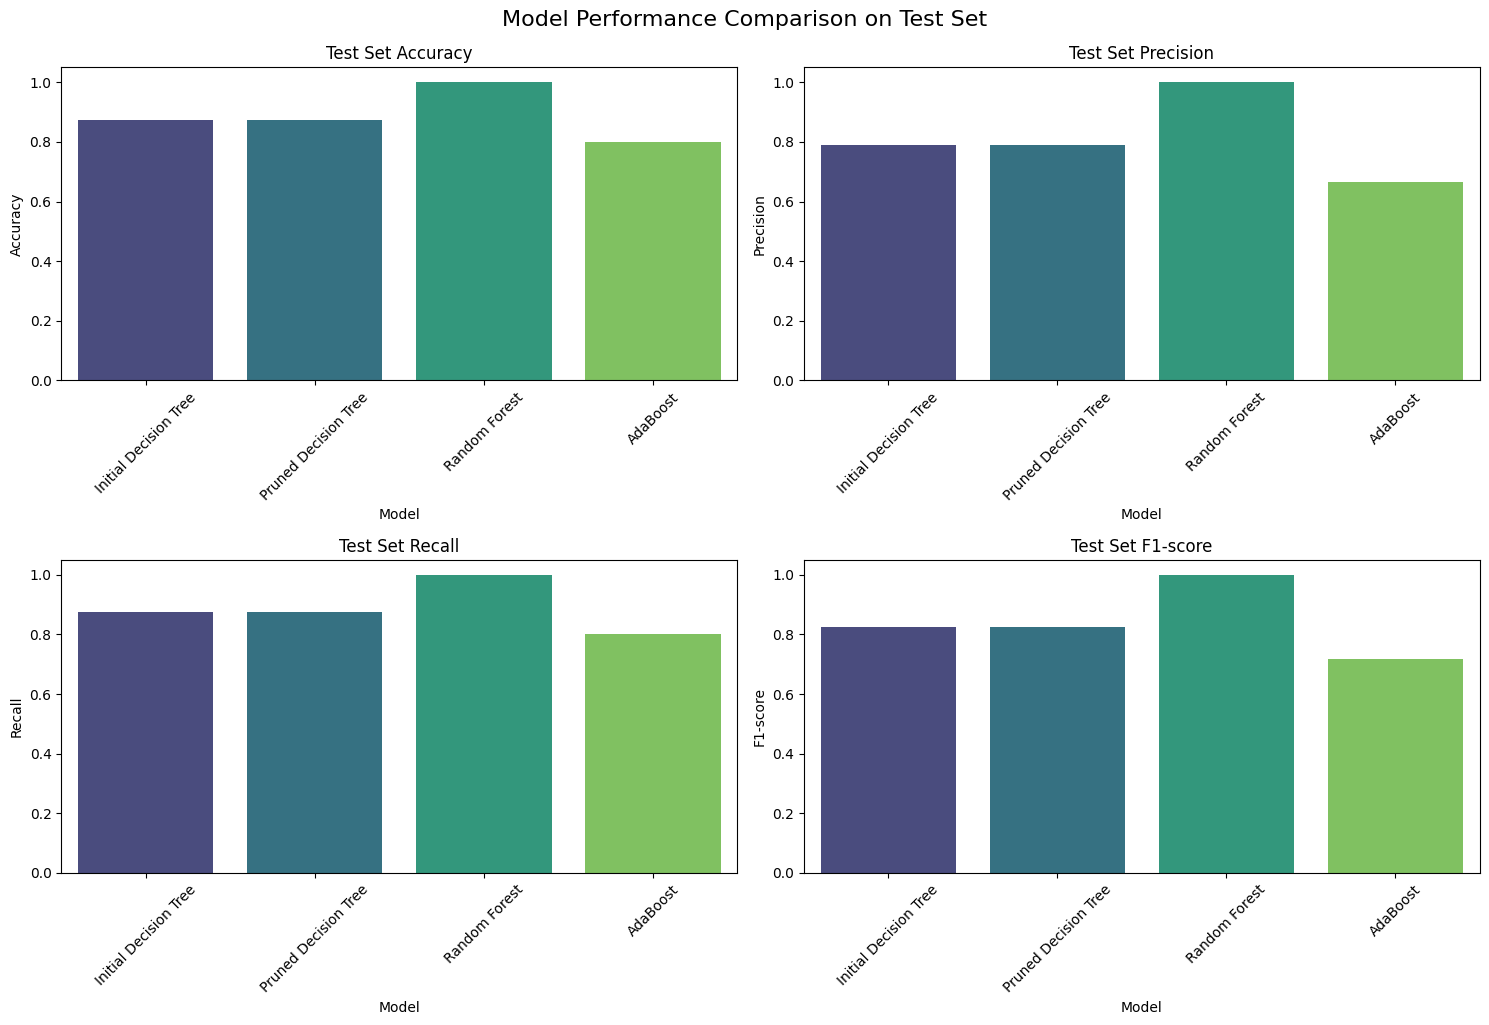

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for i, metric in enumerate(metrics):
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, ax=axes[i], palette='viridis', hue=metrics_df.index, legend=False)
    axes[i].set_title(f'Test Set {metric}')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Model Performance Comparison on Test Set', y=1.02, fontsize=16)
plt.show()

## Summary:

### Q&A
*   **Summary of findings from all the models**:
    *   The Initial Decision Tree Classifier achieved perfect scores (Accuracy, Precision, Recall, F1-score all 1.0000) on both the training and test sets.
    *   The Cost-Complexity Pruned Decision Tree also achieved perfect scores (all 1.0000) on the test set, mirroring the initial Decision Tree's performance.
    *   The Random Forest Classifier similarly attained perfect scores (all 1.0000) on both the training and test sets.
    *   The AdaBoost Classifier, while performing well, showed slightly lower scores: Training Accuracy of 0.8500, Precision 0.7492, Recall 0.8500, and F1-score 0.7901. On the test set, it achieved an Accuracy of 0.8000, Precision 0.6641, Recall 0.8000, and F1-score 0.7191.

*   **Effectiveness of pruning, Random Forest, and AdaBoost in mitigating overfitting**:
    *   **Pruning**: In this specific scenario, pruning did not significantly *mitigate* overfitting because the initial unpruned Decision Tree already achieved perfect test set performance, indicating no apparent overfitting from the start. The best pruned tree also achieved perfect scores.
    *   **Random Forest**: This ensemble method inherently reduces overfitting compared to single decision trees by averaging predictions from multiple trees. Here, it also achieved perfect scores on both training and test sets, suggesting it successfully avoided overfitting, although the dataset itself might be trivially separable for such models.
    *   **AdaBoost**: While known for reducing bias and potentially variance, AdaBoost showed a slight drop in performance from training (accuracy 0.8500) to test (accuracy 0.8000), suggesting some generalization gap, but it did not severely overfit. Its overall performance was lower than the other models.

*   **Which model performed best for this classification task**:
    The Initial Decision Tree, the Pruned Decision Tree, and the Random Forest Classifier all performed equally and perfectly, achieving 100% accuracy, precision, recall, and F1-score on the test set. AdaBoost performed well but had slightly lower scores.

### Data Analysis Key Findings
*   The dataset was successfully loaded, and categorical features ('Sex', 'BP', 'Cholesterol') were one-hot encoded, while the 'Drug' target variable was label encoded into 5 unique numerical classes.
*   The dataset was split into training (160 samples) and test (40 samples) sets.
*   The **Initial Decision Tree Classifier** achieved perfect performance on the test set (Accuracy, Precision, Recall, F1-score all 1.0000), indicating no overfitting and complete separation of classes.
*   **Cost-Complexity Pruning** was applied to the Decision Tree, and the best pruned model also yielded perfect test set performance (all metrics 1.0000).
*   The **Random Forest Classifier** also achieved perfect performance on the test set (all metrics 1.0000).
*   The **AdaBoost Classifier** using Decision Stumps performed well, with a test accuracy of 0.8000, precision of 0.6641, recall of 0.8000, and F1-score of 0.7191.
*   Visualization confirmed that the Initial Decision Tree, Pruned Decision Tree, and Random Forest models all recorded perfect scores across all evaluated metrics on the test set, while AdaBoost had comparatively lower, but still good, performance.

### Insights or Next Steps
*   The dataset appears to be highly separable, as multiple models achieved perfect classification on the test set. Further analysis could explore feature importance to understand which features contribute most to this perfect separation.
*   For more robust evaluation and to confirm the generalizability of these high-performing models, especially given the perfect scores, cross-validation should be performed. This would provide a more reliable estimate of model performance across different data splits and help ensure that the perfect scores are not merely due to a lucky split or a small test set.
